# Tutorial: Build Autodiff + MLP + SGD/Adam from Scratch

Audience:
- You know Python basics and some calculus.
- You want to internalize backprop deeply, not just use frameworks.

Core objective:
- Rebuild a micrograd-like scalar autodiff engine and MLP training loop yourself.
- Understand every gradient path and learn how to debug wrong gradients.

By the end you can:
- Implement `Value` with reverse-mode autodiff.
- Implement `Module` / `Neuron` / `Layer` / `MLP`.
- Train with both SGD and Adam.
- Diagnose common training/backprop bugs quickly.


## How To Use This Notebook

1. Run top-to-bottom once.
2. On second pass, pause before each code cell and predict output.
3. On third pass, copy the core cells into a blank notebook and rebuild from memory.

Rules for internalization:
- Do not skip gradient-check cells.
- Do not copy-paste the final implementation first.
- When stuck, isolate one operation (`+`, `*`, `**`, `relu`) and test with finite differences.


## Outline

1. Intuition: chain rule on tiny scalar graphs.
2. Implement `Value` and reverse-mode backprop.
3. Verify gradients with finite differences.
4. Build neural network layers on top.
5. Train with SGD and Adam.
6. Visualize learning curves + decision boundary.
7. Debugging playbook and exercises.


In [26]:
from __future__ import annotations

import math
import random

SEED = 1337
random.seed(SEED)

try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except Exception as exc:
    HAVE_MPL = False
    print('matplotlib unavailable, plotting cells will be skipped:', exc)


def assert_close(actual: float, expected: float, tol: float = 1e-6, msg: str = ''):
    if abs(actual - expected) > tol:
        raise AssertionError(f"{msg} expected={expected} actual={actual}")


SEED, HAVE_MPL


(1337, True)

## 1) Intuition: chain rule on a tiny scalar graph

Suppose
$$
f(x, y, z) = x y + z
$$
Then the local derivatives are:
- $\frac{\partial f}{\partial x} = y$
- $\frac{\partial f}{\partial y} = x$
- $\frac{\partial f}{\partial z} = 1$

These are exactly what backprop will propagate on edges of a computation graph.


In [27]:
x, y, z = 2.0, -3.0, 10.0
f = x * y + z

manual = {
    'df/dx': y,
    'df/dy': x,
    'df/dz': 1.0,
}


def finite_diff_1var(g, v, eps=1e-6):
    return (g(v + eps) - g(v - eps)) / (2 * eps)

num_dx = finite_diff_1var(lambda x_: x_ * y + z, x)
num_dy = finite_diff_1var(lambda y_: x * y_ + z, y)
num_dz = finite_diff_1var(lambda z_: x * y + z_, z)

print('f =', f)
print('manual:', manual)
print('numeric:', {'df/dx': num_dx, 'df/dy': num_dy, 'df/dz': num_dz})


f = 4.0
manual: {'df/dx': -3.0, 'df/dy': 2.0, 'df/dz': 1.0}
numeric: {'df/dx': -2.9999999999752447, 'df/dy': 2.000000000279556, 'df/dz': 0.9999999992515995}


### Illustration: forward values and backward signals

Single neuron pre-activation:
$$
n = x_1 w_1 + x_2 w_2 + b, \quad o = \mathrm{ReLU}(n)
$$

Backward flow for this graph:
- Start with $\frac{\partial o}{\partial o}=1$.
- Move backward node-by-node using local derivatives.
- Accumulate at nodes with multiple downstream paths.


In [28]:
# Manual backprop on one scalar neuron core (all floats, no autograd class yet)
# Choose values so n != 0 to avoid ReLU-kink ambiguity in finite differences.
x1, x2 = 2.0, 0.0
w1, w2 = -3.0, 1.0
b = 6.7

n = x1 * w1 + x2 * w2 + b
o = n if n > 0 else 0.0

# Backprop: do/do = 1
do_do = 1.0
do_dn = (1.0 if n > 0 else 0.0) * do_do

# n = x1*w1 + x2*w2 + b
do_dx1 = w1 * do_dn
do_dw1 = x1 * do_dn
do_dx2 = w2 * do_dn
do_dw2 = x2 * do_dn
do_db = 1.0 * do_dn

print('forward n, o:', n, o)
print('manual grads:', {
    'do/dx1': do_dx1,
    'do/dw1': do_dw1,
    'do/dx2': do_dx2,
    'do/dw2': do_dw2,
    'do/db': do_db,
})


def neuron_forward(vals):
    x1_, x2_, w1_, w2_, b_ = vals
    n_ = x1_ * w1_ + x2_ * w2_ + b_
    return n_ if n_ > 0 else 0.0


def finite_diff_vec(f, vals, idx, eps=1e-6):
    vp = list(vals)
    vm = list(vals)
    vp[idx] += eps
    vm[idx] -= eps
    return (f(vp) - f(vm)) / (2 * eps)

vals = [x1, x2, w1, w2, b]
names = ['x1', 'x2', 'w1', 'w2', 'b']
for i, name in enumerate(names):
    print(f'numeric do/d{name} =', finite_diff_vec(neuron_forward, vals, i))


forward n, o: 0.7000000000000002 0.7000000000000002
manual grads: {'do/dx1': -3.0, 'do/dw1': 2.0, 'do/dx2': 1.0, 'do/dw2': 0.0, 'do/db': 1.0}
numeric do/dx1 = -2.9999999999752447
numeric do/dx2 = 1.000000000139778
numeric do/dw1 = 2.000000000279556
numeric do/dw2 = 0.0
numeric do/db = 1.000000000139778


### Local derivative cheat sheet (you should memorize this)

For output node `out`:
- `out = a + b`:
  - `dout/da = 1`
  - `dout/db = 1`
- `out = a * b`:
  - `dout/da = b`
  - `dout/db = a`
- `out = a**k`:
  - `dout/da = k * a**(k-1)`
- `out = relu(a)`:
  - `dout/da = 1 if a > 0 else 0`

Backprop rule at each edge:
- `parent.grad += local_derivative * out.grad`


## 2) Implement `Value`: scalar + gradient + graph links

Design of each `Value`:
- `data`: scalar forward value.
- `grad`: d(final_output)/d(this_node), filled during backward.
- `_prev`: direct parents in graph.
- `_backward`: closure for local chain-rule logic.

`backward()` steps:
1. Build topological order of the DAG from output node.
2. Seed output gradient with 1.
3. Traverse reversed topo and call each node's `_backward`.


In [29]:
class Value:
    """A scalar value with automatic differentiation support."""

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), 'only int/float powers supported'
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data ** (other - 1.0)) * out.grad

        out._backward = _backward
        return out

    def relu(self):
        out = Value(0.0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (1.0 if out.data > 0 else 0.0) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    # Convenience operators
    def __neg__(self):
        return self * -1

    def __radd__(self, other):
        return self + other

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * (other ** -1)

    def __rtruediv__(self, other):
        return other * (self ** -1)


### Unit checks for core ops

Run these whenever you modify the engine.
If one fails, your local backward rule is wrong or gradients are not accumulating correctly.


In [30]:
# Check add/mul path
A = Value(2.0)
B = Value(-3.0)
C = Value(10.0)
D = A * B + C
D.backward()

assert_close(D.data, 4.0, msg='forward D')
assert_close(A.grad, -3.0, msg='dD/dA')
assert_close(B.grad, 2.0, msg='dD/dB')
assert_close(C.grad, 1.0, msg='dD/dC')

print('core add/mul check passed')


core add/mul check passed


In [31]:
# Check gradient accumulation on a shared node: y = x*x + x
x = Value(3.0)
y = x * x + x
y.backward()

# dy/dx = 2*x + 1 = 7
assert_close(y.data, 12.0, msg='forward y')
assert_close(x.grad, 7.0, msg='dy/dx accumulation')

print('shared-node accumulation check passed, dy/dx =', x.grad)


shared-node accumulation check passed, dy/dx = 7.0


### Inspect graph topology order

Topological order ensures children are processed before parents in reverse traversal.


In [32]:
def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def topo_order(root):
    topo = []
    visited = set()

    def build(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build(child)
            topo.append(v)

    build(root)
    return topo


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
d = a * b; d.label = 'd'
e = d + c; e.label = 'e'
f = e.relu(); f.label = 'f'

order = topo_order(f)
print('topological order (forward):')
for i, node in enumerate(order):
    name = node.label if node.label else '(anon)'
    print(f"{i:02d} label={name:>4} op={node._op:>5} data={node.data:>8.4f}")


topological order (forward):
00 label=   a op=      data=  2.0000
01 label=   b op=      data= -3.0000
02 label=   d op=    * data= -6.0000
03 label=   c op=      data= 10.0000
04 label=   e op=    + data=  4.0000
05 label=   f op= ReLU data=  4.0000


### Smoke test: the classic micrograd example

If this matches expected forward value and gradients, your engine is very likely correct.


In [33]:
a = Value(-4.0)
b = Value(2.0)
c = a + b
d = a * b + b ** 3
c = c + c + 1
c = c + 1 + c + (-a)
d = d + d * 2 + (b + a).relu()
d = d + 3 * d + (b - a).relu()
e = c - d
f = e ** 2
g = f / 2.0
g = g + 10.0 / f

print(f"forward g = {g.data:.4f}")
g.backward()
print(f"dg/da = {a.grad:.4f}")
print(f"dg/db = {b.grad:.4f}")

assert_close(g.data, 24.7041, tol=1e-4, msg='g forward')
assert_close(a.grad, 138.8338, tol=1e-3, msg='dg/da')
assert_close(b.grad, 645.5773, tol=1e-3, msg='dg/db')
print('classic example check passed')


forward g = 24.7041
dg/da = 138.8338
dg/db = 645.5773
classic example check passed


## 3) Finite-difference gradient checker

This is your strongest debugging tool for autograd engines.

Given scalar function $f(\theta)$:
$$
\frac{\partial f}{\partial \theta_i} \approx \frac{f(\theta_i + \varepsilon) - f(\theta_i - \varepsilon)}{2\varepsilon}
$$
Use this to compare against autograd for random test points.


In [34]:
def scalar_program(a_data: float, b_data: float):
    a = Value(a_data)
    b = Value(b_data)
    y = ((a * b + a + 2.0).relu() * (b ** 2)) + a / (b - 0.5)
    return y, a, b


def scalar_program_float(a_data: float, b_data: float) -> float:
    relu_arg = a_data * b_data + a_data + 2.0
    relu = relu_arg if relu_arg > 0 else 0.0
    return relu * (b_data ** 2) + a_data / (b_data - 0.5)


def finite_diff_2var(f, a_data: float, b_data: float, wrt: str, eps: float = 1e-6) -> float:
    if wrt == 'a':
        return (f(a_data + eps, b_data) - f(a_data - eps, b_data)) / (2 * eps)
    if wrt == 'b':
        return (f(a_data, b_data + eps) - f(a_data, b_data - eps)) / (2 * eps)
    raise ValueError("wrt must be 'a' or 'b'")


y, a, b = scalar_program(-1.5, 2.0)
y.backward()

num_da = finite_diff_2var(scalar_program_float, -1.5, 2.0, 'a')
num_db = finite_diff_2var(scalar_program_float, -1.5, 2.0, 'b')

print(f"autograd da={a.grad:.6f}, finite-diff da={num_da:.6f}")
print(f"autograd db={b.grad:.6f}, finite-diff db={num_db:.6f}")
assert_close(a.grad, num_da, tol=1e-5, msg='check da')
assert_close(b.grad, num_db, tol=1e-5, msg='check db')
print('finite-difference check passed')


autograd da=0.666667, finite-diff da=0.666667
autograd db=0.666667, finite-diff db=0.666667
finite-difference check passed


## 4) Build MLP primitives

We now stack scalar graph operations into trainable neural nets.

API:
- `Module`: base class with `parameters()` and `zero_grad()`.
- `Neuron`: weighted sum + optional ReLU.
- `Layer`: list of neurons.
- `MLP`: list of layers.


In [35]:
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0

    def parameters(self):
        return []


class Neuron(Module):
    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1.0, 1.0)) for _ in range(nin)]
        self.b = Value(0.0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        kind = 'ReLU' if self.nonlin else 'Linear'
        return f"{kind}Neuron({len(self.w)})"


class Layer(Module):
    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer([{', '.join(str(n) for n in self.neurons)}])"


class MLP(Module):
    def __init__(self, nin, nouts):
        sizes = [nin] + list(nouts)
        self.layers = [
            Layer(sizes[i], sizes[i + 1], nonlin=(i != len(nouts) - 1))
            for i in range(len(nouts))
        ]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP([{', '.join(str(layer) for layer in self.layers)}])"


In [36]:
random.seed(SEED)
probe = MLP(3, [4, 4, 1])
print(probe)
print('number of params:', len(probe.parameters()))

# Parameter count check: (3*4 + 4) + (4*4 + 4) + (4*1 + 1) = 41
assert len(probe.parameters()) == 41
print('parameter count check passed')


MLP([Layer([ReLUNeuron(3), ReLUNeuron(3), ReLUNeuron(3), ReLUNeuron(3)]), Layer([ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4)]), Layer([LinearNeuron(4)])])
number of params: 41
parameter count check passed


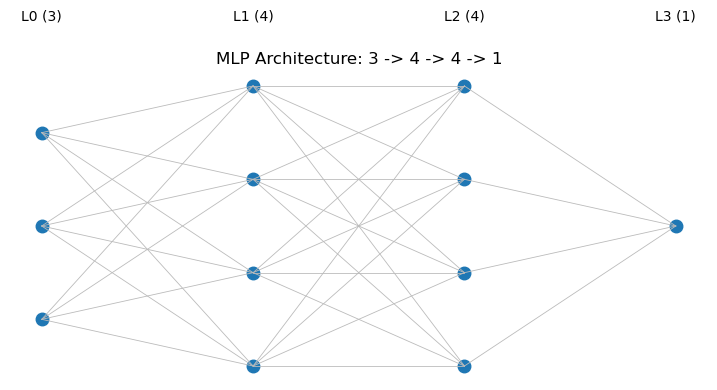

In [37]:
if not HAVE_MPL:
    print('Skipping architecture illustration (matplotlib missing).')
else:
    layer_sizes = [3, 4, 4, 1]
    x_positions = [0.0, 1.5, 3.0, 4.5]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.set_title('MLP Architecture: 3 -> 4 -> 4 -> 1')
    ax.axis('off')

    node_pos = []
    for li, size in enumerate(layer_sizes):
        ys = [j - (size - 1) / 2 for j in range(size)]
        for yi in ys:
            node_pos.append((li, x_positions[li], yi))
            ax.plot(x_positions[li], yi, 'o', color='#1f77b4', markersize=9)

    for li in range(len(layer_sizes) - 1):
        left = [(x, y) for l, x, y in node_pos if l == li]
        right = [(x, y) for l, x, y in node_pos if l == li + 1]
        for x1, y1 in left:
            for x2, y2 in right:
                ax.plot([x1, x2], [y1, y2], color='#bbbbbb', linewidth=0.6)

    for li, size in enumerate(layer_sizes):
        ax.text(x_positions[li], 2.2, f'L{li} ({size})', ha='center', fontsize=10)

    plt.show()


## 5) Dataset + margin loss

We use a tiny binary classification dataset with labels in `{+1, -1}`.

Loss:
- Data term: hinge-style margin loss `relu(1 - y * score)`.
- Regularization: L2 penalty on parameters.


In [38]:
X = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
y = [1.0, -1.0, -1.0, 1.0]


def margin_loss(model, xs, ys, alpha=1e-4):
    scores = [model([Value(xi) for xi in x]) for x in xs]
    losses = [(1.0 + (-yi) * scorei).relu() for yi, scorei in zip(ys, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    reg_loss = alpha * sum((p * p for p in model.parameters()))
    total_loss = data_loss + reg_loss

    acc = sum((yi > 0) == (scorei.data > 0) for yi, scorei in zip(ys, scores)) / len(ys)
    return total_loss, acc


def make_model(seed=SEED):
    random.seed(seed)
    return MLP(3, [4, 4, 1])


model0 = make_model()
L0, A0 = margin_loss(model0, X, y)
print(f'initial loss={L0.data:.4f}, acc={A0:.2f}')


initial loss=0.9816, acc=0.50


## 6) Optimizers and training loop

SGD update:
$$
\theta \leftarrow \theta - \eta \nabla_\theta L
$$

Adam update per parameter:
- $m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$
- $v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$
- bias correct and update.


In [39]:
class SGD:
    def __init__(self, params, lr=0.05):
        self.params = list(params)
        self.lr = lr

    def step(self):
        for p in self.params:
            p.data -= self.lr * p.grad


class Adam:
    def __init__(self, params, lr=0.03, betas=(0.9, 0.999), eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.t = 0
        self.m = [0.0 for _ in self.params]
        self.v = [0.0 for _ in self.params]

    def step(self):
        self.t += 1
        for i, p in enumerate(self.params):
            g = p.grad
            self.m[i] = self.beta1 * self.m[i] + (1.0 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1.0 - self.beta2) * (g * g)
            m_hat = self.m[i] / (1.0 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1.0 - self.beta2 ** self.t)
            p.data -= self.lr * m_hat / (math.sqrt(v_hat) + self.eps)


def grad_l2_norm(params):
    return math.sqrt(sum((p.grad * p.grad for p in params)))


def train(model, optimizer, xs, ys, steps=120, report_every=30, zero_each_step=True):
    history = {'loss': [], 'acc': [], 'grad_norm': []}

    for step in range(steps):
        total_loss, acc = margin_loss(model, xs, ys)

        if zero_each_step:
            model.zero_grad()

        total_loss.backward()
        gn = grad_l2_norm(model.parameters())
        optimizer.step()

        history['loss'].append(total_loss.data)
        history['acc'].append(acc)
        history['grad_norm'].append(gn)

        if step % report_every == 0 or step == steps - 1:
            print(f"step={step:03d} loss={total_loss.data:.4f} acc={acc:.2f} grad_norm={gn:.4f}")

    return history


In [40]:
# Fair comparison: same initialization seed
model_sgd = make_model(seed=SEED)
model_adam = make_model(seed=SEED)

hist_sgd = train(model_sgd, SGD(model_sgd.parameters(), lr=0.05), X, y, steps=120, report_every=40)
hist_adam = train(model_adam, Adam(model_adam.parameters(), lr=0.03), X, y, steps=120, report_every=40)

print("\nFinal metrics:")
print(f"SGD  -> loss={hist_sgd['loss'][-1]:.4f}, acc={hist_sgd['acc'][-1]:.2f}")
print(f"Adam -> loss={hist_adam['loss'][-1]:.4f}, acc={hist_adam['acc'][-1]:.2f}")


step=000 loss=0.9816 acc=0.50 grad_norm=1.5643
step=040 loss=0.0263 acc=1.00 grad_norm=0.3173
step=080 loss=0.0011 acc=1.00 grad_norm=0.0007
step=119 loss=0.0011 acc=1.00 grad_norm=0.0007
step=000 loss=0.9816 acc=0.50 grad_norm=1.5643
step=040 loss=0.0014 acc=1.00 grad_norm=0.0008
step=080 loss=0.0015 acc=1.00 grad_norm=0.0008
step=119 loss=0.0015 acc=1.00 grad_norm=0.0008

Final metrics:
SGD  -> loss=0.0011, acc=1.00
Adam -> loss=0.0015, acc=1.00


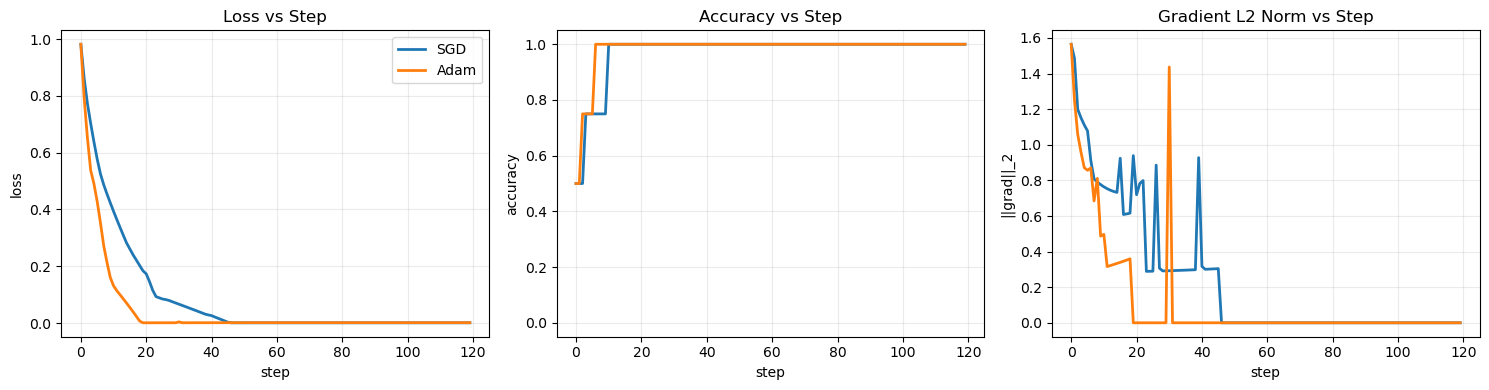

In [41]:
if not HAVE_MPL:
    print('Skipping optimizer plots (matplotlib missing).')
else:
    steps = list(range(len(hist_sgd['loss'])))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(steps, hist_sgd['loss'], label='SGD', linewidth=2)
    axes[0].plot(steps, hist_adam['loss'], label='Adam', linewidth=2)
    axes[0].set_title('Loss vs Step')
    axes[0].set_xlabel('step')
    axes[0].set_ylabel('loss')
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(steps, hist_sgd['acc'], label='SGD', linewidth=2)
    axes[1].plot(steps, hist_adam['acc'], label='Adam', linewidth=2)
    axes[1].set_title('Accuracy vs Step')
    axes[1].set_xlabel('step')
    axes[1].set_ylabel('accuracy')
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].grid(alpha=0.25)

    axes[2].plot(steps, hist_sgd['grad_norm'], label='SGD', linewidth=2)
    axes[2].plot(steps, hist_adam['grad_norm'], label='Adam', linewidth=2)
    axes[2].set_title('Gradient L2 Norm vs Step')
    axes[2].set_xlabel('step')
    axes[2].set_ylabel('||grad||_2')
    axes[2].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


## 7) 2D visualization: decision boundary on a moon-like dataset

This section gives geometric intuition for what the MLP is learning.


In [42]:
def make_two_moons(n=140, noise=0.09, seed=7):
    random.seed(seed)
    xs, ys = [], []

    for _ in range(n // 2):
        t = random.uniform(0.0, math.pi)
        xs.append([math.cos(t) + random.gauss(0.0, noise), math.sin(t) + random.gauss(0.0, noise)])
        ys.append(1.0)

    for _ in range(n // 2):
        t = random.uniform(0.0, math.pi)
        xs.append([1.0 - math.cos(t) + random.gauss(0.0, noise), -math.sin(t) - 0.5 + random.gauss(0.0, noise)])
        ys.append(-1.0)

    return xs, ys


def margin_loss_points(model, xs, ys, alpha=1e-4):
    scores = [model([Value(x0), Value(x1)]) for x0, x1 in xs]
    losses = [(1.0 + (-yi) * s).relu() for yi, s in zip(ys, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    reg_loss = alpha * sum((p * p for p in model.parameters()))
    total = data_loss + reg_loss
    acc = sum((yi > 0) == (s.data > 0) for yi, s in zip(ys, scores)) / len(ys)
    return total, acc


def train_points(model, optimizer, xs, ys, steps=140, report_every=35):
    hist = {'loss': [], 'acc': []}
    for step in range(steps):
        L, A = margin_loss_points(model, xs, ys)
        model.zero_grad()
        L.backward()
        optimizer.step()
        hist['loss'].append(L.data)
        hist['acc'].append(A)
        if step % report_every == 0 or step == steps - 1:
            print(f'step={step:03d} loss={L.data:.4f} acc={A:.2f}')
    return hist


X2, y2 = make_two_moons(n=140, noise=0.09, seed=7)
random.seed(SEED)
model2 = MLP(2, [16, 16, 1])
hist2 = train_points(model2, Adam(model2.parameters(), lr=0.03), X2, y2, steps=140)


step=000 loss=0.9291 acc=0.50
step=035 loss=0.0097 acc=1.00
step=070 loss=0.0090 acc=1.00
step=105 loss=0.0084 acc=1.00
step=139 loss=0.0079 acc=1.00


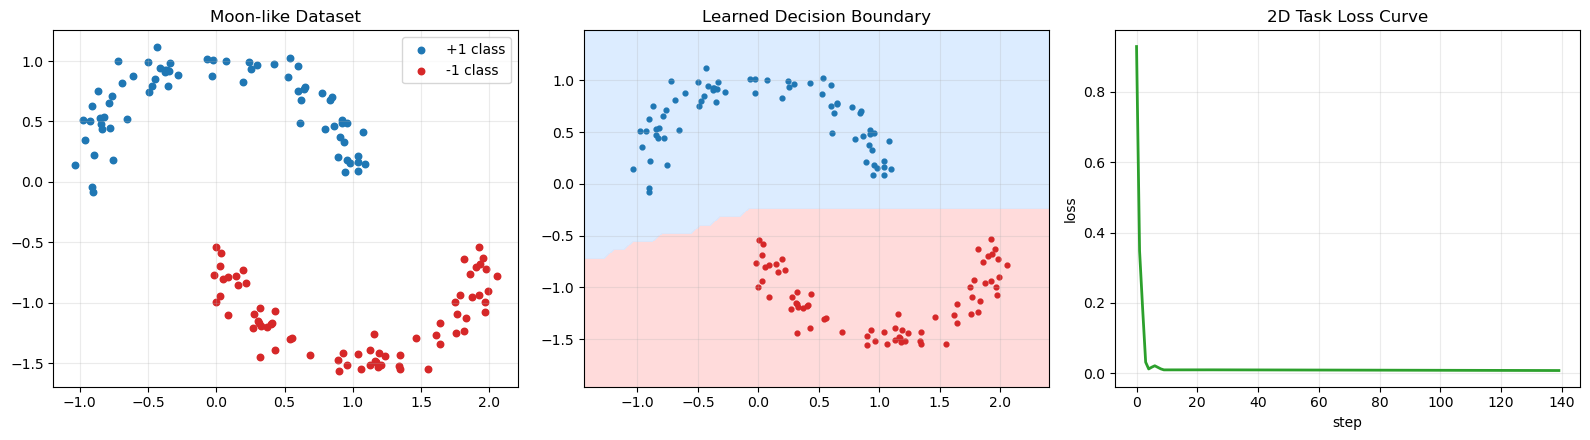

In [43]:
if not HAVE_MPL:
    print('Skipping decision-boundary plots (matplotlib missing).')
else:
    pos = [x for x, yi in zip(X2, y2) if yi > 0]
    neg = [x for x, yi in zip(X2, y2) if yi < 0]

    x_min = min(x[0] for x in X2) - 0.4
    x_max = max(x[0] for x in X2) + 0.4
    y_min = min(x[1] for x in X2) - 0.4
    y_max = max(x[1] for x in X2) + 0.4

    h = 0.08
    grid_x = []
    gx = x_min
    while gx <= x_max:
        grid_x.append(gx)
        gx += h

    grid_y = []
    gy = y_min
    while gy <= y_max:
        grid_y.append(gy)
        gy += h

    Z = []
    for yy in grid_y:
        row = []
        for xx in grid_x:
            score = model2([Value(xx), Value(yy)]).data
            row.append(1 if score > 0 else 0)
        Z.append(row)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    axes[0].scatter([x[0] for x in pos], [x[1] for x in pos], s=22, color='#1f77b4', label='+1 class')
    axes[0].scatter([x[0] for x in neg], [x[1] for x in neg], s=22, color='#d62728', label='-1 class')
    axes[0].set_title('Moon-like Dataset')
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].contourf(grid_x, grid_y, Z, levels=[-0.1, 0.5, 1.1], colors=['#ffd5d5', '#d6e9ff'], alpha=0.85)
    axes[1].scatter([x[0] for x in pos], [x[1] for x in pos], s=12, color='#1f77b4')
    axes[1].scatter([x[0] for x in neg], [x[1] for x in neg], s=12, color='#d62728')
    axes[1].set_title('Learned Decision Boundary')
    axes[1].grid(alpha=0.25)

    steps = list(range(len(hist2['loss'])))
    axes[2].plot(steps, hist2['loss'], linewidth=2, color='#2ca02c')
    axes[2].set_title('2D Task Loss Curve')
    axes[2].set_xlabel('step')
    axes[2].set_ylabel('loss')
    axes[2].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


### Extra illustrations from the original micrograd repo

- Computation graph snapshot:
![Computation Graph](../../gout.svg)

- Decision boundary from the original notebook:
![Moon MLP](../../moon_mlp.png)


## 8) Debugging playbook (read this before writing your own)

Typical failures and fixes:

1. Loss does not decrease at all.
- Check `backward()` is called.
- Check `optimizer.step()` actually updates `p.data`.
- Verify labels/sign in margin loss.

2. Training behaves strangely after a few steps.
- You might be forgetting `zero_grad()`.
- This accumulates gradients across steps and silently changes updates.

3. Numerical instability / explosion.
- Learning rate too high.
- Try lower LR or use Adam.

4. Wrong gradient for one variable.
- Use finite-difference checks on the smallest possible graph.
- Verify local derivative implementation for that operation.


step=000 loss=0.9816 acc=0.50 grad_norm=1.5643
step=020 loss=0.0061 acc=1.00 grad_norm=4.9930
step=040 loss=0.0253 acc=1.00 grad_norm=8.8137
step=059 loss=0.2773 acc=1.00 grad_norm=45.0167
step=000 loss=0.9816 acc=0.50 grad_norm=1.5643
step=020 loss=0.0504 acc=1.00 grad_norm=0.2975
step=040 loss=0.0011 acc=1.00 grad_norm=0.0007
step=059 loss=0.0011 acc=1.00 grad_norm=0.0007

Buggy final loss: 0.2773 best: 0.0012
Clean final loss: 0.0011 best: 0.0011


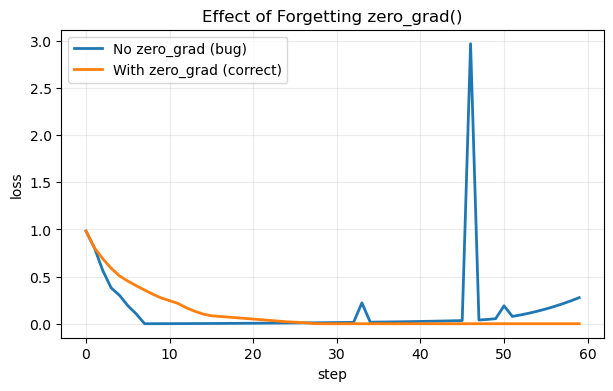

In [44]:
# Demonstrate the zero_grad bug clearly
buggy = make_model(seed=SEED)
clean = make_model(seed=SEED)

hist_buggy = train(buggy, SGD(buggy.parameters(), lr=0.08), X, y, steps=60, report_every=20, zero_each_step=False)
hist_clean = train(clean, SGD(clean.parameters(), lr=0.08), X, y, steps=60, report_every=20, zero_each_step=True)

print("\nBuggy final loss:", round(hist_buggy['loss'][-1], 4), 'best:', round(min(hist_buggy['loss']), 4))
print('Clean final loss:', round(hist_clean['loss'][-1], 4), 'best:', round(min(hist_clean['loss']), 4))

if HAVE_MPL:
    s = list(range(len(hist_buggy['loss'])))
    plt.figure(figsize=(7, 4))
    plt.plot(s, hist_buggy['loss'], label='No zero_grad (bug)', linewidth=2)
    plt.plot(s, hist_clean['loss'], label='With zero_grad (correct)', linewidth=2)
    plt.title('Effect of Forgetting zero_grad()')
    plt.xlabel('step')
    plt.ylabel('loss')
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()


## 9) Self-check tests (minimum bar before moving on)

If these pass, your implementation is in good shape.


In [45]:
def run_self_checks():
    # 1) shared-node gradient accumulation
    x = Value(5.0)
    y = x * x + x
    y.backward()
    assert_close(x.grad, 11.0, msg='shared node grad')

    # 2) relu branch correctness
    u = Value(-2.0)
    v = u.relu()
    v.backward()
    assert_close(u.grad, 0.0, msg='relu negative grad')

    # 3) finite-difference consistency on random points
    random.seed(123)
    for _ in range(5):
        a0 = random.uniform(-2.0, 2.0)
        b0 = random.uniform(0.8, 2.2)  # keep away from denominator singularity
        yv, a, b = scalar_program(a0, b0)
        yv.backward()
        nda = finite_diff_2var(scalar_program_float, a0, b0, 'a')
        ndb = finite_diff_2var(scalar_program_float, a0, b0, 'b')
        assert_close(a.grad, nda, tol=1e-4, msg='random da check')
        assert_close(b.grad, ndb, tol=1e-4, msg='random db check')

    print('all self-checks passed')


run_self_checks()


all self-checks passed


## 10) Exercises (do these to internalize)

1. Add `tanh()` to `Value` and use tanh in hidden layers.
2. Implement SGD with momentum and compare to SGD/Adam curves.
3. Replace hinge loss with MSE on a tiny regression dataset.
4. Write a tiny `gradcheck(fn, params)` utility that works for any scalar-output function.

Stretch goal:
- Rebuild this entire notebook in a new blank file without looking.


In [46]:
# Exercise scaffolds

# 1) Value.tanh sketch:
# def tanh(self):
#     t = math.tanh(self.data)
#     out = Value(t, (self,), 'tanh')
#     def _backward():
#         self.grad += (1.0 - t * t) * out.grad
#     out._backward = _backward
#     return out

# 2) Momentum SGD sketch:
# v = mu * v - lr * grad
# p.data += v

# 3) MSE sketch:
# losses = [(pred - target)**2 for pred, target in zip(preds, targets)]
# total = sum(losses) * (1.0 / len(losses))

print('Fill these in, then rerun relevant sections.')


Fill these in, then rerun relevant sections.


## Final Checklist

You have internalized the core when you can do all of this from scratch:
- Implement `Value` with correct backprop for `+`, `*`, `**`, `relu`.
- Explain why topological order is needed.
- Explain gradient accumulation on shared nodes.
- Train an MLP and get non-trivial learning curves.
- Debug a wrong gradient using finite differences.

If you can do that in a blank notebook in under ~90 minutes, you are in excellent shape.
